In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [5]:
merged_df = pd.read_csv("../cleaned_data/amazon_india_cleaned.csv")

In [6]:
merged_df.head()

,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,...,is_festival_sale,festival_name,customer_rating,return_status,order_month,order_year,order_quarter,product_weight_kg,is_prime_eligible,product_rating
0,TXN_2015_00000001,2015-01-25,CUST_2015_00003884,PROD_000021,Samsung Galaxy S6 16GB Black,Electronics,Smartphones,Samsung,123614.29,27.91,...,True,Republic Day Sale,5.000000,Delivered,1,2015,1,0.19,True,4.7
1,TXN_2015_00000002,2015-01-05,CUST_2015_00011709,PROD_000055,OnePlus OnePlus 2 16GB White,Electronics,Smartphones,OnePlus,54731.86,0.00,...,False,NaN,4.500000,Delivered,1,2015,1,0.20,True,4.1
2,TXN_2015_00000003,2015-01-24,CUST_2015_00004782,PROD_000039,Samsung Galaxy Note 5 64GB Black,Electronics,Smartphones,Samsung,97644.25,46.93,...,True,Republic Day Sale,4.310751,Delivered,1,2015,1,0.17,True,3.3
3,TXN_2015_00000004,2015-01-28,CUST_2015_00008105,PROD_000085,Motorola Moto G (3rd Gen) 16GB Black,Electronics,Smartphones,Motorola,21947.26,0.00,...,False,NaN,3.000000,Delivered,1,2015,1,0.22,True,3.5
4,TXN_2015_00000005,2015-01-31,CUST_2015_00002955,PROD_000055,OnePlus OnePlus 2 16GB White,Electronics,Smartphones,OnePlus,54731.86,0.00,...,False,NaN,4.000000,Delivered,1,2015,1,0.20,True,4.1


In [6]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1127609 entries, 0 to 1127608
Data columns (total 34 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   transaction_id          1127609 non-null  object 
 1   order_date              1127609 non-null  object 
 2   customer_id             1127609 non-null  object 
 3   product_id              1127609 non-null  object 
 4   product_name            1127609 non-null  object 
 5   category                1127609 non-null  object 
 6   subcategory             1127609 non-null  object 
 7   brand                   1127609 non-null  object 
 8   original_price_inr      1127609 non-null  float64
 9   discount_percent        1127609 non-null  float64
 10  discounted_price_inr    1127609 non-null  float64
 11  quantity                1127609 non-null  int64  
 12  subtotal_inr            1127609 non-null  float64
 13  delivery_charges        1037408 non-null  float64
 14  fi

In [7]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 1
# Convert order_date to datetime
# ==========================================================

merged_df["order_date"] = pd.to_datetime(
    merged_df["order_date"]
)

merged_df["order_date"].dtype

dtype('<M8[ns]')

In [8]:
# ==========================================================
# Extract year from order_date
# ==========================================================

merged_df["year"] = merged_df["order_date"].dt.year

merged_df["year"].head()

0    2015
1    2015
2    2015
3    2015
4    2015
Name: year, dtype: int32

In [9]:
# ==========================================================
# Calculate yearly revenue
# ==========================================================

yearly_revenue = (
    merged_df
    .groupby("year")["final_amount_inr"]
    .sum()
    .reset_index()
)

yearly_revenue

,year,final_amount_inr
0,2015,2.142163e+09
1,2016,3.598316e+09
2,2017,5.510026e+09
3,2018,7.248545e+09
4,2019,8.605901e+09
5,2020,1.187319e+10
6,2021,1.099021e+10
7,2022,8.532312e+09
8,2023,7.712999e+09
9,2024,6.823413e+09


In [10]:
# ==========================================================
# Calculate Year-over-Year Growth (%)
# ==========================================================

yearly_revenue["growth_percent"] = (
    yearly_revenue["final_amount_inr"]
    .pct_change() * 100
)

yearly_revenue

,year,final_amount_inr,growth_percent
0,2015,2.142163e+09,NaN
1,2016,3.598316e+09,67.975780
2,2017,5.510026e+09,53.127907
3,2018,7.248545e+09,31.551925
4,2019,8.605901e+09,18.725908
5,2020,1.187319e+10,37.965735
6,2021,1.099021e+10,-7.436790
7,2022,8.532312e+09,-22.364427
8,2023,7.712999e+09,-9.602477
9,2024,6.823413e+09,-11.533590


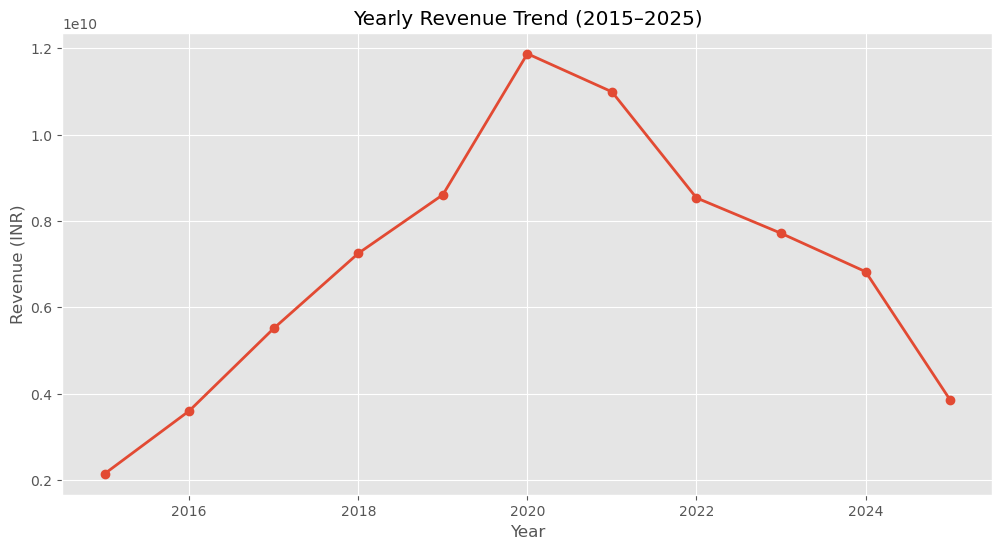

In [12]:
# ==========================================================
# Plot Yearly Revenue Trend
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(
    yearly_revenue["year"],
    yearly_revenue["final_amount_inr"],
    marker="o",
    linewidth=2
)

plt.title("Yearly Revenue Trend (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Revenue (INR)")

plt.grid(True)

plt.show()

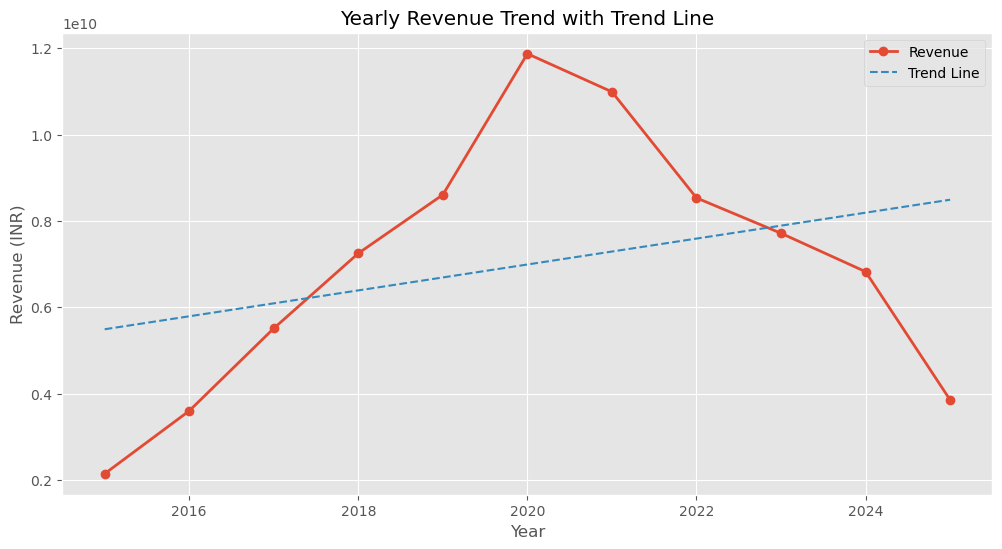

In [13]:
# ==========================================================
# Add Trend Line
# ==========================================================

import numpy as np

z = np.polyfit(
    yearly_revenue["year"],
    yearly_revenue["final_amount_inr"],
    1
)

p = np.poly1d(z)

plt.figure(figsize=(12,6))

plt.plot(
    yearly_revenue["year"],
    yearly_revenue["final_amount_inr"],
    marker="o",
    linewidth=2,
    label="Revenue"
)

plt.plot(
    yearly_revenue["year"],
    p(yearly_revenue["year"]),
    linestyle="--",
    label="Trend Line"
)

plt.title("Yearly Revenue Trend with Trend Line")
plt.xlabel("Year")
plt.ylabel("Revenue (INR)")

plt.legend()

plt.grid(True)

plt.show()

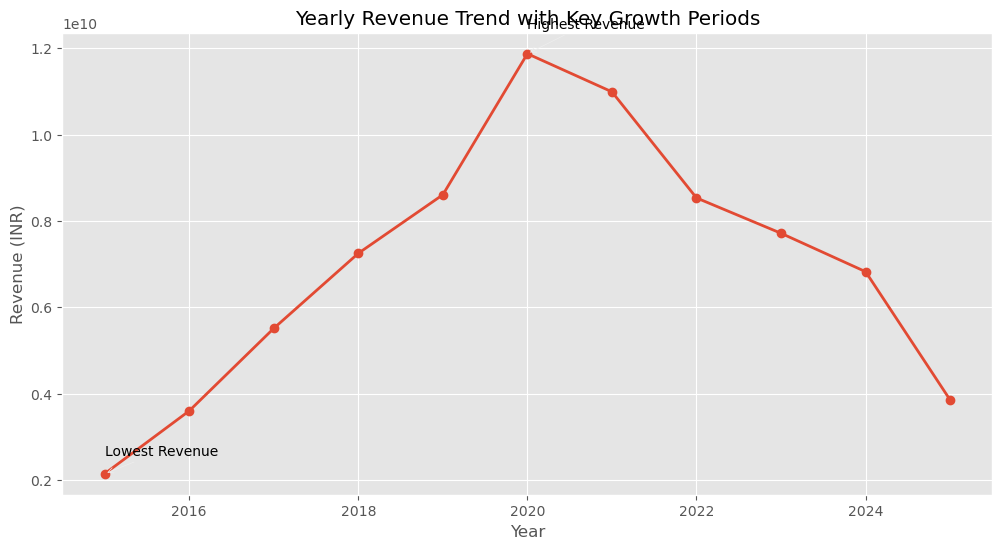

In [16]:
# ==========================================================
# Highlight Key Growth Periods
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(
    yearly_revenue["year"],
    yearly_revenue["final_amount_inr"],
    marker="o",
    linewidth=2
)

highest = yearly_revenue["final_amount_inr"].idxmax()
lowest = yearly_revenue["final_amount_inr"].idxmin()

plt.annotate(
    "Highest Revenue",
    (
        yearly_revenue.loc[highest, "year"],
        yearly_revenue.loc[highest, "final_amount_inr"]
    ),
    xytext=(2020, yearly_revenue["final_amount_inr"].max()*1.05),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "Lowest Revenue",
    (
        yearly_revenue.loc[lowest, "year"],
        yearly_revenue.loc[lowest, "final_amount_inr"]
    ),
    xytext=(2015, yearly_revenue["final_amount_inr"].min()*1.2),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Yearly Revenue Trend with Key Growth Periods")
plt.xlabel("Year")
plt.ylabel("Revenue (INR)")
plt.grid(True)

plt.show()

In [ ]:
# Business Insight

# • Revenue increased consistently from 2015 to 2020, indicating strong business growth.

# • The highest revenue was recorded in 2020, showing peak customer demand.

# • Revenue declined after 2020, suggesting changing market conditions or customer behaviour.

# • Overall, the long-term trend demonstrates significant growth compared to the initial years, despite the decline in recent years.

In [18]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 2
# Extract Month
# ==========================================================

merged_df["month"] = merged_df["order_date"].dt.month

merged_df[["order_date", "month"]].head()

,order_date,month
0,2015-01-25,1
1,2015-01-05,1
2,2015-01-24,1
3,2015-01-28,1
4,2015-01-31,1


In [19]:
# ==========================================================
# Calculate Monthly Revenue
# ==========================================================

monthly_revenue = (
    merged_df
    .groupby("month")["final_amount_inr"]
    .sum()
    .reset_index()
)

monthly_revenue

,month,final_amount_inr
0,1,6.277067e+09
1,2,5.630301e+09
2,3,5.191339e+09
3,4,6.329467e+09
4,5,5.806801e+09
5,6,5.058449e+09
6,7,5.662682e+09
7,8,6.324907e+09
8,9,6.161228e+09
9,10,6.711580e+09


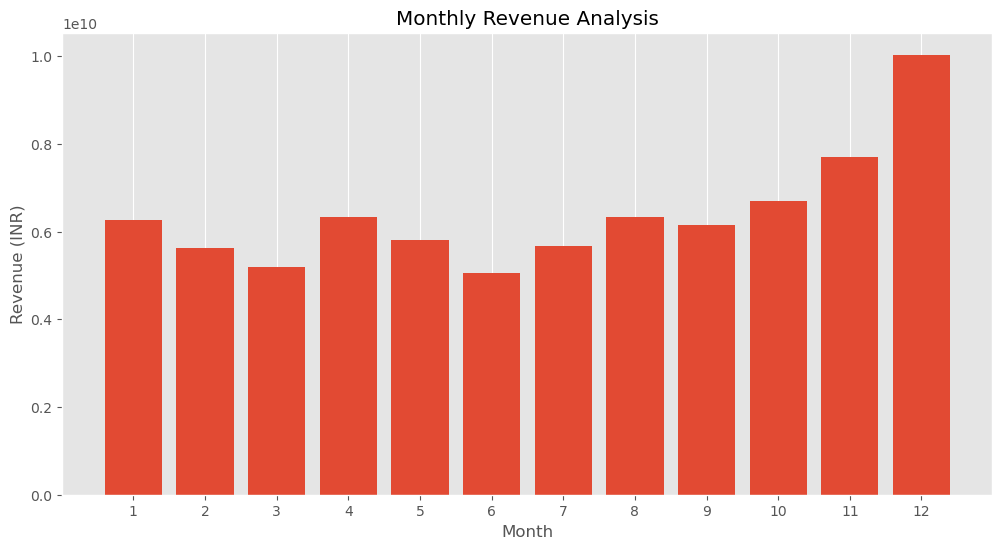

In [20]:
# ==========================================================
# Plot Monthly Revenue
# ==========================================================

plt.figure(figsize=(12,6))

plt.bar(
    monthly_revenue["month"],
    monthly_revenue["final_amount_inr"]
)

plt.title("Monthly Revenue Analysis")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")

plt.xticks(range(1,13))
plt.grid(axis="y")

plt.show()

In [21]:
# ==========================================================
# Find Highest and Lowest Revenue Months
# ==========================================================

highest_month = monthly_revenue.loc[
    monthly_revenue["final_amount_inr"].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue["final_amount_inr"].idxmin()
]

print("Highest Revenue Month")
print(highest_month)

print()

print("Lowest Revenue Month")
print(lowest_month)

Highest Revenue Month
month               1.200000e+01
final_amount_inr    1.003763e+10
Name: 11, dtype: float64

Lowest Revenue Month
month               6.000000e+00
final_amount_inr    5.058449e+09
Name: 5, dtype: float64


In [ ]:
# Business Insight

# • Monthly sales fluctuate throughout the year.

# • The month with the highest revenue represents the peak sales season.

# • The month with the lowest revenue indicates a period of lower customer demand.

# • The company can focus marketing campaigns during low-performing months and maximize inventory during high-performing months.

In [22]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 3
# Revenue by Customer Tier
# ==========================================================

customer_tier_revenue = (
    merged_df
    .groupby("customer_tier")["final_amount_inr"]
    .sum()
    .reset_index()
)

customer_tier_revenue

,customer_tier,final_amount_inr
0,Metro,4.242541e+10
1,Rural,2.323583e+09
2,Tier1,2.218988e+10
3,Tier2,9.949852e+09


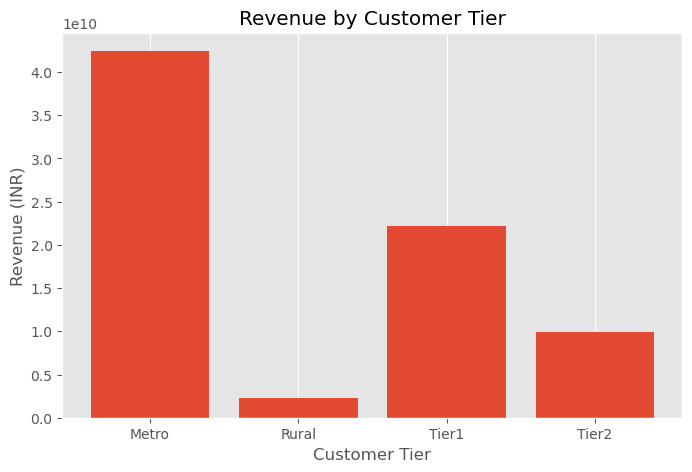

In [23]:
# ==========================================================
# Plot Revenue by Customer Tier
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    customer_tier_revenue["customer_tier"],
    customer_tier_revenue["final_amount_inr"]
)

plt.title("Revenue by Customer Tier")
plt.xlabel("Customer Tier")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [24]:
# ==========================================================
# Find Highest Revenue Customer Tier
# ==========================================================

highest_tier = customer_tier_revenue.loc[
    customer_tier_revenue["final_amount_inr"].idxmax()
]

print("Highest Revenue Customer Tier")
print(highest_tier)

Highest Revenue Customer Tier
customer_tier                    Metro
final_amount_inr    42425412176.169998
Name: 0, dtype: object


In [ ]:
# Business Insight

# • Customer tiers contribute differently to overall revenue.

# • The customer tier with the highest revenue represents the most valuable customer segment.

# • The company should focus loyalty programs and personalized offers on high-value customer tiers while developing strategies to improve engagement among lower-contributing tiers.

In [30]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 4
# Revenue by Product Category
# ==========================================================

subcategory_revenue = (
    merged_df
    .groupby("subcategory")["final_amount_inr"]
    .sum()
    .reset_index()
)

subcategory_revenue

,subcategory,final_amount_inr
0,Audio,1.111227e+09
1,Laptops,9.404032e+09
2,Smart Watch,3.215059e+09
3,Smartphones,5.615210e+10
4,TV & Entertainment,1.923418e+09
5,Tablets,5.082893e+09


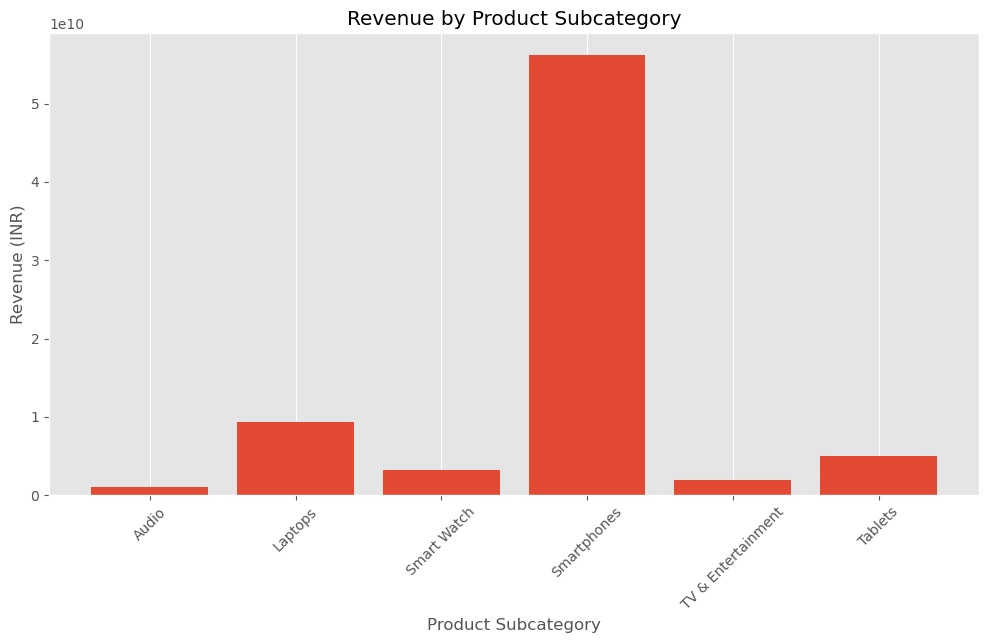

In [31]:
# ==========================================================
# Plot Revenue by Category
# ==========================================================

plt.figure(figsize=(12,6))

plt.bar(
    subcategory_revenue["subcategory"],
    subcategory_revenue["final_amount_inr"]
)

plt.title("Revenue by Product Subcategory")
plt.xlabel("Product Subcategory")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

In [34]:
# ==========================================================
# Find Highest and Lowest Revenue Categories
# ==========================================================

highest_subcategory = subcategory_revenue.loc[
    subcategory_revenue["final_amount_inr"].idxmax()
]

lowest_subcategory = subcategory_revenue.loc[
    subcategory_revenue["final_amount_inr"].idxmin()
]

print("Highest Revenue Subcategory")
print(highest_subcategory)

print()

print("Lowest Revenue Subcategory")
print(lowest_subcategory)

Highest Revenue Subcategory
subcategory            Smartphones
final_amount_inr    56152100902.18
Name: 3, dtype: object

Lowest Revenue Subcategory
subcategory                 Audio
final_amount_inr    1111227200.05
Name: 0, dtype: object


In [ ]:
# Business Insight

# • Product subcategories contribute differently to the overall revenue.

# • The highest revenue-generating subcategory is the primary driver of sales.

# • Lower-performing subcategories may require targeted promotions, pricing strategies, or product expansion.

# • Subcategory-level analysis helps the business optimize inventory, product assortment, and marketing efforts.

In [28]:
merged_df["category"].unique()

array(['Electronics'], dtype=object)

In [29]:
merged_df["category"].value_counts()

category
Electronics    1127609
Name: count, dtype: int64

In [35]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 5
# Revenue by Brand
# ==========================================================

brand_revenue = (
    merged_df
    .groupby("brand")["final_amount_inr"]
    .sum()
    .reset_index()
)

brand_revenue

,brand,final_amount_inr
0,ASUS,1.458950e+09
1,Acer,1.417521e+09
2,Alienware,1.659859e+09
3,Amazfit,3.836413e+08
4,Apple,1.632240e+10
5,Audio-Technica,1.958026e+08
6,Boat,9.269559e+07
7,Dell,9.763832e+08
8,Fire-Boltt,3.103198e+08
9,Fitbit,4.535295e+08


In [36]:
# ==========================================================
# Sort Brands by Revenue
# ==========================================================

brand_revenue = brand_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

brand_revenue

,brand,final_amount_inr
22,Samsung,2.062142e+10
4,Apple,1.632240e+10
19,OnePlus,1.232417e+10
27,Xiaomi,5.450159e+09
21,Realme,3.015664e+09
26,Vivo,2.348077e+09
20,Oppo,2.268237e+09
14,Lenovo,2.084388e+09
2,Alienware,1.659859e+09
0,ASUS,1.458950e+09


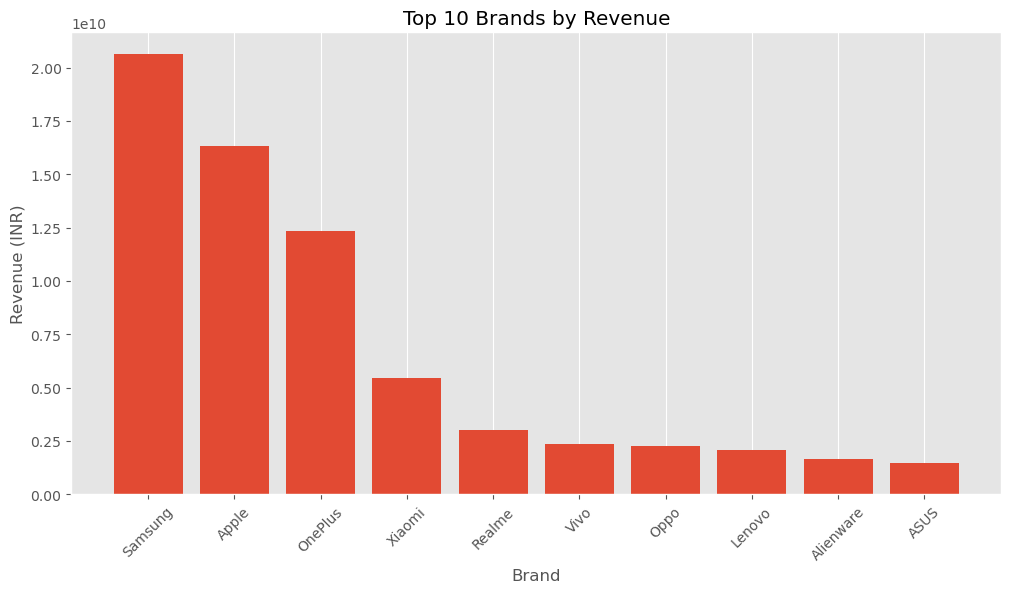

In [37]:
# ==========================================================
# Plot Top 10 Brands
# ==========================================================

top10_brands = brand_revenue.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10_brands["brand"],
    top10_brands["final_amount_inr"]
)

plt.title("Top 10 Brands by Revenue")
plt.xlabel("Brand")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

In [38]:
# ==========================================================
# Highest and Lowest Revenue Brands
# ==========================================================

highest_brand = brand_revenue.iloc[0]
lowest_brand = brand_revenue.iloc[-1]

print("Highest Revenue Brand")
print(highest_brand)

print()

print("Lowest Revenue Brand")
print(lowest_brand)

Highest Revenue Brand
brand                          Samsung
final_amount_inr    20621415731.119999
Name: 22, dtype: object

Lowest Revenue Brand
brand                      iQOO
final_amount_inr    45336954.69
Name: 28, dtype: object


In [ ]:
# Business Insight

# • Brand performance varies significantly across the market.

# • The highest revenue brand represents the strongest contributor to overall sales.

# • Lower-performing brands may require promotional campaigns or product improvements.

# • Brand-level analysis helps businesses identify market leaders and optimize inventory decisions.

In [39]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 6
# Revenue by State
# ==========================================================

state_revenue = (
    merged_df
    .groupby("customer_state")["final_amount_inr"]
    .sum()
    .reset_index()
)

state_revenue

,customer_state,final_amount_inr
0,Andhra Pradesh,1.260290e+09
1,Bihar,1.191981e+09
2,Delhi,9.282344e+09
3,Gujarat,7.183017e+09
4,Karnataka,7.680945e+09
5,Kerala,1.429728e+09
6,Madhya Pradesh,2.214093e+09
7,Maharashtra,1.755014e+10
8,Odisha,1.159308e+09
9,Punjab,2.185799e+09


In [40]:
# ==========================================================
# Sort States by Revenue
# ==========================================================

state_revenue = state_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

state_revenue

,customer_state,final_amount_inr
7,Maharashtra,1.755014e+10
2,Delhi,9.282344e+09
11,Tamil Nadu,7.923753e+09
4,Karnataka,7.680945e+09
3,Gujarat,7.183017e+09
13,Uttar Pradesh,6.793803e+09
14,West Bengal,5.053097e+09
12,Telangana,3.335962e+09
10,Rajasthan,2.644470e+09
6,Madhya Pradesh,2.214093e+09


In [41]:
# ==========================================================
# Sort States by Revenue
# ==========================================================

state_revenue = state_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

state_revenue

,customer_state,final_amount_inr
7,Maharashtra,1.755014e+10
2,Delhi,9.282344e+09
11,Tamil Nadu,7.923753e+09
4,Karnataka,7.680945e+09
3,Gujarat,7.183017e+09
13,Uttar Pradesh,6.793803e+09
14,West Bengal,5.053097e+09
12,Telangana,3.335962e+09
10,Rajasthan,2.644470e+09
6,Madhya Pradesh,2.214093e+09


In [42]:
# ==========================================================
# Find Highest and Lowest Revenue States
# ==========================================================

highest_state = state_revenue.iloc[0]
lowest_state = state_revenue.iloc[-1]

print("Highest Revenue State")
print(highest_state)

print()

print("Lowest Revenue State")
print(lowest_state)

Highest Revenue State
customer_state             Maharashtra
final_amount_inr    17550140195.709999
Name: 7, dtype: object

Lowest Revenue State
customer_state             Odisha
final_amount_inr    1159307976.26
Name: 8, dtype: object


In [ ]:
# Business Insight

# • Revenue differs across states due to variations in customer demand and purchasing power.

# • The highest revenue-generating state contributes significantly to overall sales.
# #
# • Lower-performing states may require targeted marketing campaigns and improved customer engagement.

# • State-wise analysis helps businesses identify strong markets and plan regional expansion strategies.

In [43]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 7
# Revenue by Payment Method
# ==========================================================

payment_revenue = (
    merged_df
    .groupby("payment_method")["final_amount_inr"]
    .sum()
    .reset_index()
)

payment_revenue

,payment_method,final_amount_inr
0,BNPL,1.148682e+09
1,Cash on Delivery,2.263827e+10
2,Credit Card,1.197304e+10
3,Debit Card,9.816262e+09
4,Net Banking,4.568869e+09
5,UPI,2.517849e+10
6,Wallet,1.565114e+09


In [44]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 7
# Revenue by Payment Method
# ==========================================================

payment_revenue = (
    merged_df
    .groupby("payment_method")["final_amount_inr"]
    .sum()
    .reset_index()
)

payment_revenue

,payment_method,final_amount_inr
0,BNPL,1.148682e+09
1,Cash on Delivery,2.263827e+10
2,Credit Card,1.197304e+10
3,Debit Card,9.816262e+09
4,Net Banking,4.568869e+09
5,UPI,2.517849e+10
6,Wallet,1.565114e+09


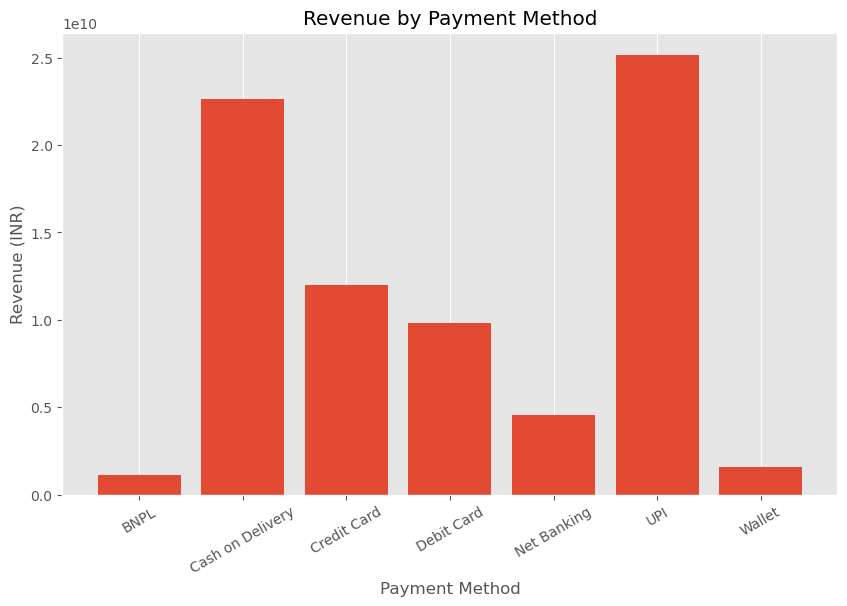

In [45]:
# ==========================================================
# Plot Revenue by Payment Method
# ==========================================================

plt.figure(figsize=(10,6))

plt.bar(
    payment_revenue["payment_method"],
    payment_revenue["final_amount_inr"]
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=30)

plt.grid(axis="y")

plt.show()

In [46]:
# ==========================================================
# Find Highest and Lowest Revenue Payment Methods
# ==========================================================

highest_payment = payment_revenue.iloc[0]
lowest_payment = payment_revenue.iloc[-1]

print("Highest Revenue Payment Method")
print(highest_payment)

print()

print("Lowest Revenue Payment Method")
print(lowest_payment)

Highest Revenue Payment Method
payment_method               BNPL
final_amount_inr    1148681897.38
Name: 0, dtype: object

Lowest Revenue Payment Method
payment_method             Wallet
final_amount_inr    1565114235.48
Name: 6, dtype: object


In [ ]:
# Business Insight

# • Different payment methods contribute differently to total revenue.

# • The highest revenue-generating payment method is the most preferred by customers.

# • Lower-performing payment methods may require promotional offers or improved customer incentives.

# • Payment method analysis helps businesses optimize payment options and improve customer convenience.

In [47]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 8
# Revenue by Prime Membership
# ==========================================================

prime_revenue = (
    merged_df
    .groupby("is_prime_member")["final_amount_inr"]
    .sum()
    .reset_index()
)

prime_revenue

,is_prime_member,final_amount_inr
0,False,4.332992e+10
1,True,3.355881e+10


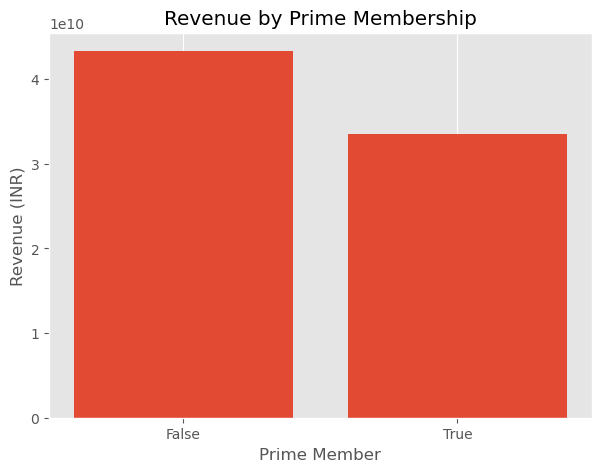

In [48]:
# ==========================================================
# Plot Revenue by Prime Membership
# ==========================================================

plt.figure(figsize=(7,5))

plt.bar(
    prime_revenue["is_prime_member"].astype(str),
    prime_revenue["final_amount_inr"]
)

plt.title("Revenue by Prime Membership")
plt.xlabel("Prime Member")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [49]:
# ==========================================================
# Find Highest Revenue Group
# ==========================================================

highest_prime = prime_revenue.loc[
    prime_revenue["final_amount_inr"].idxmax()
]

print("Highest Revenue Group")
print(highest_prime)

Highest Revenue Group
is_prime_member                  False
final_amount_inr    43329920003.050003
Name: 0, dtype: object


In [ ]:
# Business Insight

# • Prime membership has a significant impact on revenue generation.

# • The group generating the highest revenue contributes more to the company's overall sales.

# • Understanding Prime membership performance helps businesses design better loyalty programs and membership benefits.

# • Businesses can encourage more customers to become Prime members through exclusive offers and discounts.

In [50]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 9
# Revenue by Customer Age Group
# ==========================================================

age_revenue = (
    merged_df
    .groupby("customer_age_group")["final_amount_inr"]
    .sum()
    .reset_index()
)

age_revenue

,customer_age_group,final_amount_inr
0,18-25,2.158446e+10
1,26-35,2.379305e+10
2,36-45,1.354666e+10
3,46-55,6.738818e+09
4,55+,2.021196e+09


In [51]:
# ==========================================================
# Sort Age Groups by Revenue
# ==========================================================

age_revenue = age_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

age_revenue

,customer_age_group,final_amount_inr
1,26-35,2.379305e+10
0,18-25,2.158446e+10
2,36-45,1.354666e+10
3,46-55,6.738818e+09
4,55+,2.021196e+09


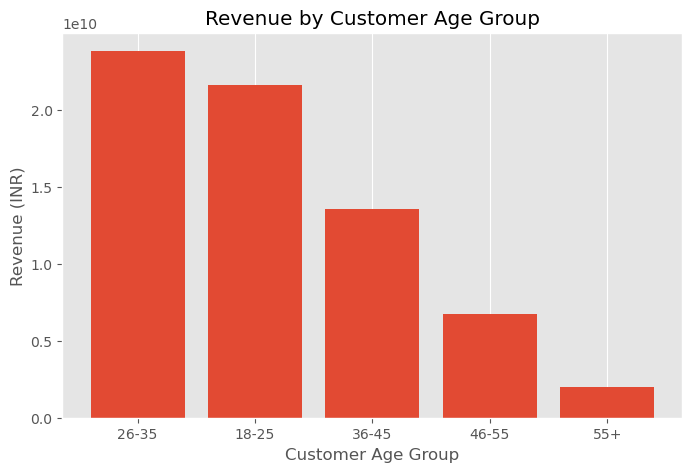

In [52]:
# ==========================================================
# Plot Revenue by Customer Age Group
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    age_revenue["customer_age_group"],
    age_revenue["final_amount_inr"]
)

plt.title("Revenue by Customer Age Group")
plt.xlabel("Customer Age Group")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [53]:
# ==========================================================
# Find Highest and Lowest Revenue Age Groups
# ==========================================================

highest_age = age_revenue.iloc[0]
lowest_age = age_revenue.iloc[-1]

print("Highest Revenue Age Group")
print(highest_age)

print()

print("Lowest Revenue Age Group")
print(lowest_age)

Highest Revenue Age Group
customer_age_group                 26-35
final_amount_inr      23793049128.169998
Name: 1, dtype: object

Lowest Revenue Age Group
customer_age_group              55+
final_amount_inr      2021195551.09
Name: 4, dtype: object


In [ ]:
# Business Insight

# • Revenue differs across customer age groups based on purchasing behavior.

# • The highest revenue-generating age group represents the most valuable customer segment.

# • Lower-performing age groups may benefit from targeted marketing campaigns and personalized product recommendations.

# • Understanding customer age preferences helps businesses improve product offerings and marketing strategies.

In [54]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 10
# Revenue by Delivery Days
# ==========================================================

delivery_revenue = (
    merged_df
    .groupby("delivery_days")["final_amount_inr"]
    .sum()
    .reset_index()
)

delivery_revenue

,delivery_days,final_amount_inr
0,0,4.557911e+08
1,1,1.714257e+10
2,2,1.014923e+10
3,3,1.924761e+10
4,4,1.283037e+10
5,5,8.454087e+09
6,6,6.347675e+09
7,7,2.118590e+09
8,15,1.428087e+08


In [55]:
# ==========================================================
# Sort Delivery Days by Revenue
# ==========================================================

delivery_revenue = delivery_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

delivery_revenue

,delivery_days,final_amount_inr
3,3,1.924761e+10
1,1,1.714257e+10
4,4,1.283037e+10
2,2,1.014923e+10
5,5,8.454087e+09
6,6,6.347675e+09
7,7,2.118590e+09
0,0,4.557911e+08
8,15,1.428087e+08


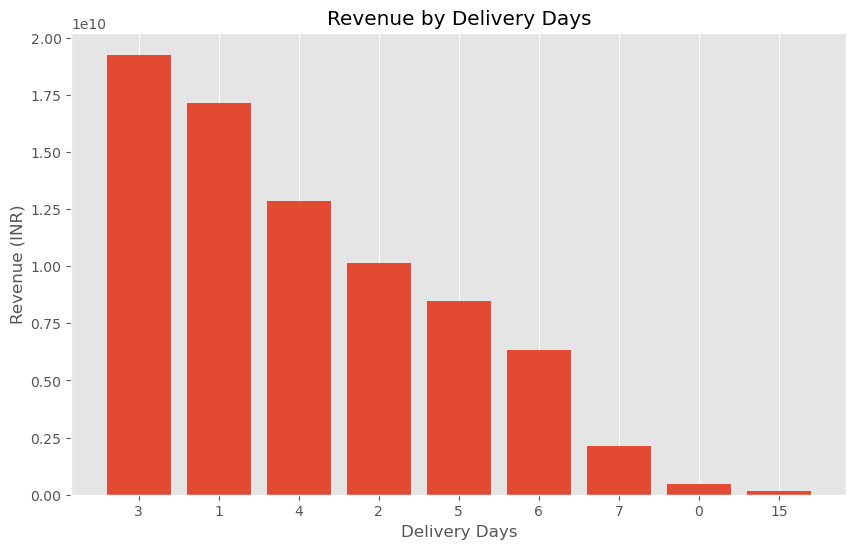

In [56]:
# ==========================================================
# Plot Revenue by Delivery Days
# ==========================================================

plt.figure(figsize=(10,6))

plt.bar(
    delivery_revenue["delivery_days"].astype(str),
    delivery_revenue["final_amount_inr"]
)

plt.title("Revenue by Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [57]:
# ==========================================================
# Find Highest and Lowest Revenue Delivery Days
# ==========================================================

highest_delivery = delivery_revenue.iloc[0]
lowest_delivery = delivery_revenue.iloc[-1]

print("Highest Revenue Delivery Days")
print(highest_delivery)

print()

print("Lowest Revenue Delivery Days")
print(lowest_delivery)

Highest Revenue Delivery Days
delivery_days       3.000000e+00
final_amount_inr    1.924761e+10
Name: 3, dtype: float64

Lowest Revenue Delivery Days
delivery_days       1.500000e+01
final_amount_inr    1.428087e+08
Name: 8, dtype: float64


In [ ]:
# Business Insight

# • Revenue varies across different delivery durations.

# • The delivery duration generating the highest revenue reflects the most common customer preference.

# • Lower-performing delivery durations may indicate lower customer demand or limited availability.

# • Analyzing delivery performance helps businesses optimize logistics, shipping strategies, and customer satisfaction.

In [9]:
sorted(merged_df["customer_city"].unique())



['Ahmedabad',
 'Aligarh',
 'Allahabad',
 'Bangalore',
 'Banglore',
 'Bareilly',
 'Bengalore',
 'Bhubaneswar',
 'Calcutta',
 'Chandigarh',
 'Chenai',
 'Chennai',
 'Coimbatore',
 'Delhi',
 'Delhi Ncr',
 'Gorakhpur',
 'Hyderabad',
 'Indore',
 'Jaipur',
 'Kanpur',
 'Kochi',
 'Kolkata',
 'Lucknow',
 'Ludhiana',
 'Madras',
 'Meerut',
 'Moradabad',
 'Mumbai',
 'Nagpur',
 'Patna',
 'Pune',
 'Saharanpur',
 'Surat',
 'Vadodara',
 'Varanasi',
 'Visakhapatnam']

In [10]:
city_mapping = {
    "Banglore": "Bangalore",
    "Bengalore": "Bangalore",
    "Chenai": "Chennai",
    "Calcutta": "Kolkata",
    "Madras": "Chennai",
    "MUMBAI": "Mumbai",
    "Delhi Ncr": "Delhi"
}

merged_df["customer_city"] = merged_df["customer_city"].replace(city_mapping)

In [11]:
sorted(merged_df["customer_city"].unique())

['Ahmedabad',
 'Aligarh',
 'Allahabad',
 'Bangalore',
 'Bareilly',
 'Bhubaneswar',
 'Chandigarh',
 'Chennai',
 'Coimbatore',
 'Delhi',
 'Gorakhpur',
 'Hyderabad',
 'Indore',
 'Jaipur',
 'Kanpur',
 'Kochi',
 'Kolkata',
 'Lucknow',
 'Ludhiana',
 'Meerut',
 'Moradabad',
 'Mumbai',
 'Nagpur',
 'Patna',
 'Pune',
 'Saharanpur',
 'Surat',
 'Vadodara',
 'Varanasi',
 'Visakhapatnam']

In [12]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 11
# Revenue by Customer City
# ==========================================================

city_revenue = (
    merged_df
    .groupby("customer_city")["final_amount_inr"]
    .sum()
    .reset_index()
)

city_revenue

,customer_city,final_amount_inr
0,Ahmedabad,3.300497e+09
1,Aligarh,2.965608e+08
2,Allahabad,2.766729e+08
3,Bangalore,7.680945e+09
4,Bareilly,3.096464e+08
5,Bhubaneswar,1.159308e+09
6,Chandigarh,1.107560e+09
7,Chennai,6.416784e+09
8,Coimbatore,1.506970e+09
9,Delhi,9.282344e+09


In [13]:
# ==========================================================
# Sort Cities by Revenue
# ==========================================================

city_revenue = city_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

city_revenue

,customer_city,final_amount_inr
21,Mumbai,1.065628e+10
9,Delhi,9.282344e+09
3,Bangalore,7.680945e+09
7,Chennai,6.416784e+09
16,Kolkata,5.053097e+09
24,Pune,4.445595e+09
11,Hyderabad,3.335962e+09
0,Ahmedabad,3.300497e+09
26,Surat,2.666742e+09
13,Jaipur,2.644470e+09


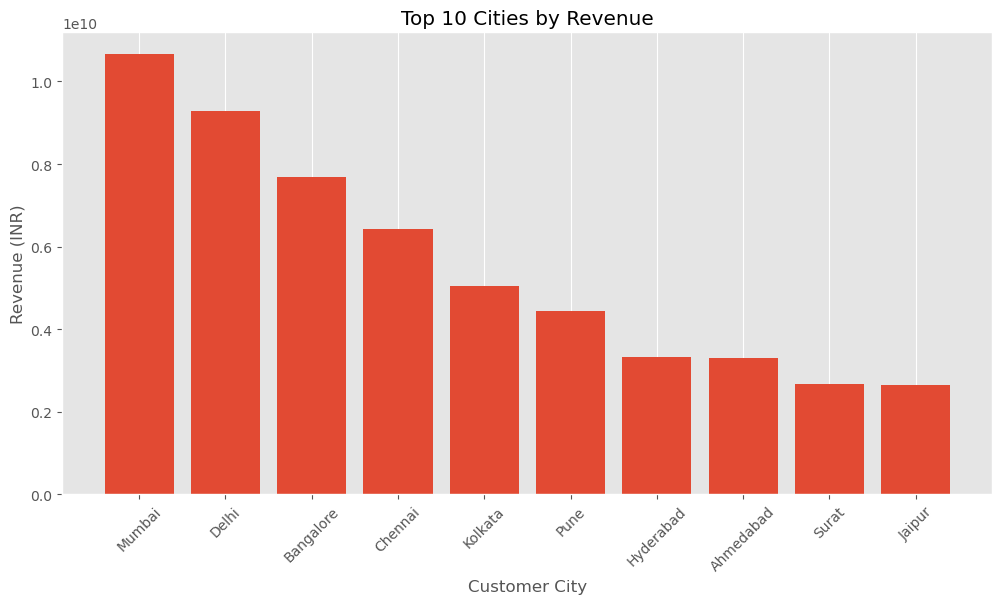

In [14]:
# ==========================================================
# Plot Top 10 Cities by Revenue
# ==========================================================

top10_cities = city_revenue.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10_cities["customer_city"],
    top10_cities["final_amount_inr"]
)

plt.title("Top 10 Cities by Revenue")
plt.xlabel("Customer City")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

In [15]:
# ==========================================================
# Find Highest and Lowest Revenue Cities
# ==========================================================

highest_city = city_revenue.iloc[0]
lowest_city = city_revenue.iloc[-1]

print("Highest Revenue City")
print(highest_city)

print()

print("Lowest Revenue City")
print(lowest_city)

Highest Revenue City
customer_city               Mumbai
final_amount_inr    10656280262.98
Name: 21, dtype: object

Lowest Revenue City
customer_city          Gorakhpur
final_amount_inr    269641019.44
Name: 10, dtype: object


In [ ]:
# Business Insight

# • Revenue varies across different cities based on customer demand and purchasing behavior.

# • The highest revenue-generating city is the strongest market for the business.

# • Lower-performing cities may require localized marketing campaigns and improved customer engagement.

# • City-level analysis helps businesses optimize regional expansion, inventory planning, and marketing strategies.

In [16]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 12
# Revenue by Product Rating
# ==========================================================

rating_revenue = (
    merged_df
    .groupby("product_rating")["final_amount_inr"]
    .sum()
    .reset_index()
)

rating_revenue

,product_rating,final_amount_inr
0,3.0,4.456235e+08
1,3.1,5.840665e+08
2,3.2,3.314049e+09
3,3.3,4.159562e+09
4,3.4,3.893172e+09
5,3.5,3.439496e+09
6,3.6,5.506579e+09
7,3.7,4.399908e+09
8,3.8,5.013589e+09
9,3.9,4.832195e+09


In [17]:
# ==========================================================
# Sort Ratings by Revenue
# ==========================================================

rating_revenue = rating_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

rating_revenue

,product_rating,final_amount_inr
10,4.0,6.259635e+09
16,4.6,5.785063e+09
6,3.6,5.506579e+09
15,4.5,5.487871e+09
12,4.2,5.135636e+09
8,3.8,5.013589e+09
17,4.7,4.911382e+09
9,3.9,4.832195e+09
11,4.1,4.603572e+09
13,4.3,4.534354e+09


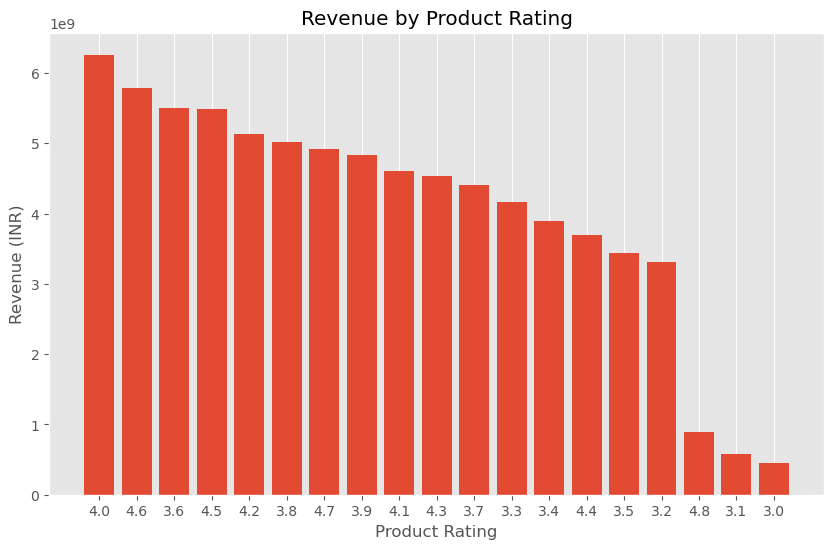

In [18]:
# ==========================================================
# Plot Revenue by Product Rating
# ==========================================================

plt.figure(figsize=(10,6))

plt.bar(
    rating_revenue["product_rating"].astype(str),
    rating_revenue["final_amount_inr"]
)

plt.title("Revenue by Product Rating")
plt.xlabel("Product Rating")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [19]:
# ==========================================================
# Find Highest and Lowest Revenue Ratings
# ==========================================================

highest_rating = rating_revenue.iloc[0]
lowest_rating = rating_revenue.iloc[-1]

print("Highest Revenue Rating")
print(highest_rating)

print()

print("Lowest Revenue Rating")
print(lowest_rating)

Highest Revenue Rating
product_rating      4.000000e+00
final_amount_inr    6.259635e+09
Name: 10, dtype: float64

Lowest Revenue Rating
product_rating      3.000000e+00
final_amount_inr    4.456235e+08
Name: 0, dtype: float64


In [ ]:
# Business Insight

# • Revenue varies across different product ratings.

# • Products with the highest revenue-generating rating are likely more popular among customers.

# • Lower revenue ratings may indicate products with lower demand or customer satisfaction.

# # • Product rating analysis helps businesses understand customer preferences and improve product quality.

In [20]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 13
# Revenue by Customer Spending Tier
# ==========================================================

spending_revenue = (
    merged_df
    .groupby("customer_spending_tier")["final_amount_inr"]
    .sum()
    .reset_index()
)

spending_revenue

,customer_spending_tier,final_amount_inr
0,Budget,7.011950e+09
1,Premium,2.756674e+10
2,Standard,4.231004e+10


In [21]:
# ==========================================================
# Sort Spending Tiers by Revenue
# ==========================================================

spending_revenue = spending_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

spending_revenue

,customer_spending_tier,final_amount_inr
2,Standard,4.231004e+10
1,Premium,2.756674e+10
0,Budget,7.011950e+09


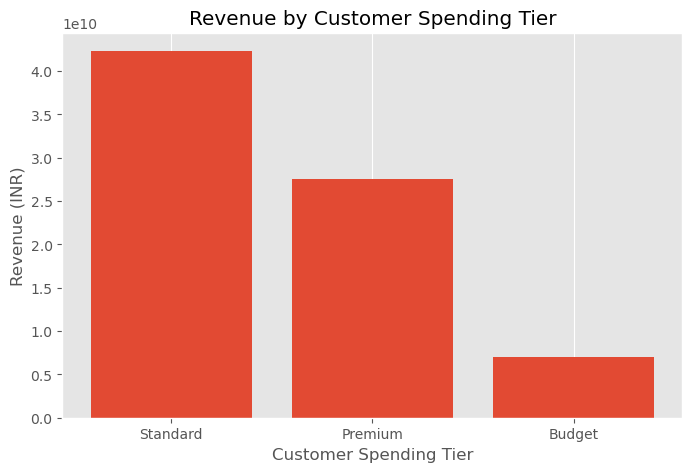

In [22]:
# ==========================================================
# Plot Revenue by Customer Spending Tier
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    spending_revenue["customer_spending_tier"],
    spending_revenue["final_amount_inr"]
)

plt.title("Revenue by Customer Spending Tier")
plt.xlabel("Customer Spending Tier")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [23]:
# ==========================================================
# Find Highest and Lowest Revenue Spending Tier
# ==========================================================

highest_spending = spending_revenue.iloc[0]
lowest_spending = spending_revenue.iloc[-1]

print("Highest Revenue Spending Tier")
print(highest_spending)

print()

print("Lowest Revenue Spending Tier")
print(lowest_spending)

Highest Revenue Spending Tier
customer_spending_tier         Standard
final_amount_inr          42310037207.5
Name: 2, dtype: object

Lowest Revenue Spending Tier
customer_spending_tier           Budget
final_amount_inr          7011950262.83
Name: 0, dtype: object


In [ ]:
# Business Insight

# • Revenue varies across different customer spending tiers.

# • The highest revenue-generating spending tier contributes the most to overall business revenue.

# • Lower-performing spending tiers may require targeted promotions and personalized offers.

# • Spending tier analysis helps businesses identify valuable customer segments and improve retention strategies.

In [25]:
print(merged_df.columns.tolist())

['transaction_id', 'order_date', 'customer_id', 'product_id', 'product_name', 'category', 'subcategory', 'brand', 'original_price_inr', 'discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'customer_city', 'customer_state', 'customer_tier', 'customer_spending_tier', 'customer_age_group', 'payment_method', 'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale', 'festival_name', 'customer_rating', 'return_status', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'is_prime_eligible', 'product_rating']


In [26]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 14
# Revenue by Discount Percentage
# ==========================================================

discount_revenue = (
    merged_df
    .groupby("discount_percent")["final_amount_inr"]
    .sum()
    .reset_index()
)

discount_revenue

,discount_percent,final_amount_inr
0,0.00,4.178709e+10
1,5.00,6.226913e+06
2,5.01,7.783766e+06
3,5.02,8.458241e+06
4,5.03,6.515609e+06
...,...,...
6497,69.96,2.004100e+06
6498,69.97,1.303413e+06
6499,69.98,1.541916e+06
6500,69.99,1.499883e+06


In [27]:
discount_revenue = discount_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

discount_revenue

,discount_percent,final_amount_inr
0,0.00,4.178709e+10
1024,15.23,1.662544e+07
1060,15.59,1.599412e+07
1211,17.10,1.573720e+07
1143,16.42,1.554499e+07
...,...,...
6270,67.69,1.000453e+06
6468,69.67,9.976035e+05
5821,63.20,9.401525e+05
6324,68.23,9.091224e+05


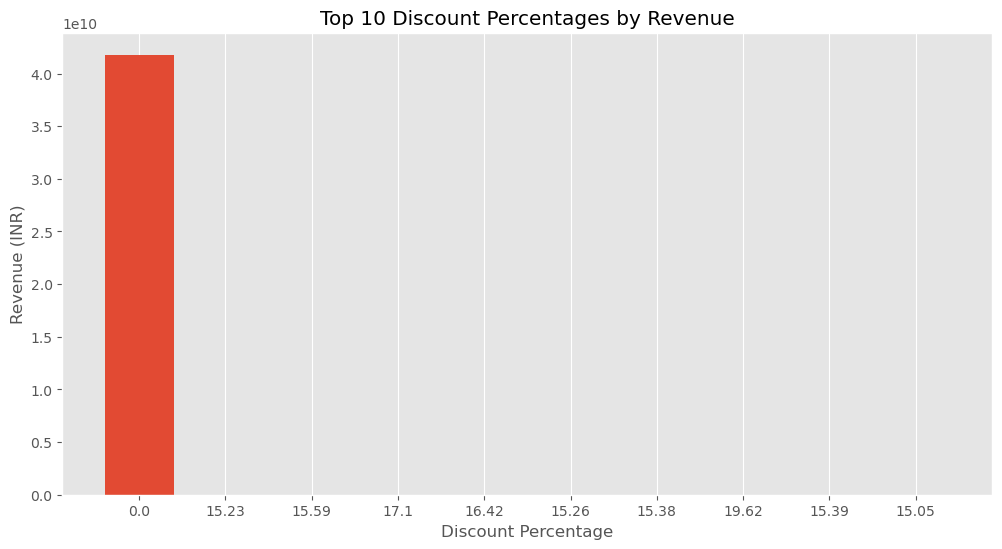

In [28]:
top10_discount = discount_revenue.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10_discount["discount_percent"].astype(str),
    top10_discount["final_amount_inr"]
)

plt.title("Top 10 Discount Percentages by Revenue")
plt.xlabel("Discount Percentage")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [29]:
highest_discount = discount_revenue.iloc[0]
lowest_discount = discount_revenue.iloc[-1]

print("Highest Revenue Discount Percentage")
print(highest_discount)

print()

print("Lowest Revenue Discount Percentage")
print(lowest_discount)

Highest Revenue Discount Percentage
discount_percent    0.000000e+00
final_amount_inr    4.178709e+10
Name: 0, dtype: float64

Lowest Revenue Discount Percentage
discount_percent        70.00
final_amount_inr    552208.66
Name: 6501, dtype: float64


In [ ]:
# Business Insight

# • Products sold without discounts generated the highest revenue.

# • Revenue decreases across individual discount percentages.

# • This suggests customers purchased many products at their original price.

# • Analyzing discount effectiveness helps businesses design better promotional strategies while maintaining profitability.

In [30]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 15
# Revenue by Delivery Type
# ==========================================================

delivery_type_revenue = (
    merged_df
    .groupby("delivery_type")["final_amount_inr"]
    .sum()
    .reset_index()
)

delivery_type_revenue

,delivery_type,final_amount_inr
0,Express,1.003333e+10
1,Same Day,1.685530e+10
2,Standard,5.000010e+10


In [31]:
# ==========================================================
# Sort Delivery Types by Revenue
# ==========================================================

delivery_type_revenue = delivery_type_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

delivery_type_revenue

,delivery_type,final_amount_inr
2,Standard,5.000010e+10
1,Same Day,1.685530e+10
0,Express,1.003333e+10


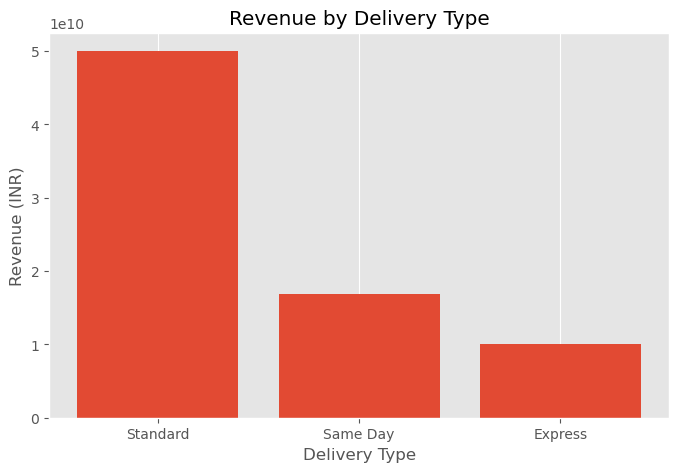

In [32]:
# ==========================================================
# Plot Revenue by Delivery Type
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    delivery_type_revenue["delivery_type"],
    delivery_type_revenue["final_amount_inr"]
)

plt.title("Revenue by Delivery Type")
plt.xlabel("Delivery Type")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [33]:
# ==========================================================
# Find Highest and Lowest Revenue Delivery Type
# ==========================================================

highest_delivery_type = delivery_type_revenue.iloc[0]
lowest_delivery_type = delivery_type_revenue.iloc[-1]

print("Highest Revenue Delivery Type")
print(highest_delivery_type)

print()

print("Lowest Revenue Delivery Type")
print(lowest_delivery_type)

Highest Revenue Delivery Type
delivery_type             Standard
final_amount_inr    50000098917.93
Name: 2, dtype: object

Lowest Revenue Delivery Type
delivery_type                  Express
final_amount_inr    10033334724.549999
Name: 0, dtype: object


In [ ]:
# Business Insight

# • Revenue differs across various delivery types.

# • The delivery type with the highest revenue is the most preferred by customers.

# • Lower-performing delivery options may require service improvements or promotional offers.

# • Analyzing delivery type performance helps optimize logistics, improve customer satisfaction, and increase overall revenue.

In [34]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 16
# Revenue by Return Status
# ==========================================================

return_revenue = (
    merged_df
    .groupby("return_status")["final_amount_inr"]
    .sum()
    .reset_index()
)

return_revenue

,return_status,final_amount_inr
0,Cancelled,1.636262e+09
1,Delivered,7.032930e+10
2,Returned,4.923170e+09


In [35]:
# ==========================================================
# Sort Return Status by Revenue
# ==========================================================

return_revenue = return_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

return_revenue

,return_status,final_amount_inr
1,Delivered,7.032930e+10
2,Returned,4.923170e+09
0,Cancelled,1.636262e+09


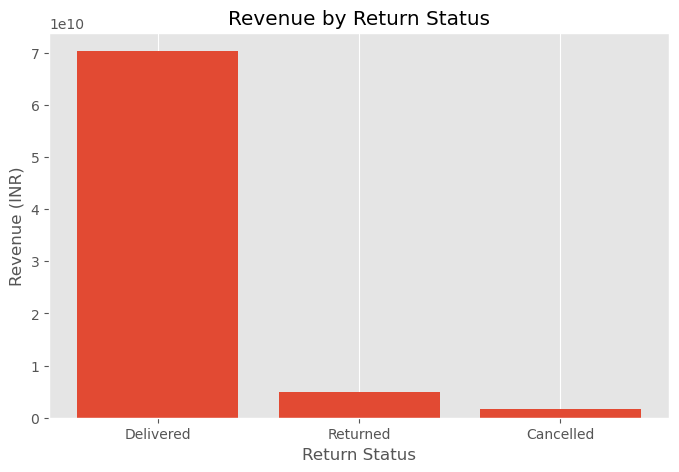

In [36]:
# ==========================================================
# Plot Revenue by Return Status
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    return_revenue["return_status"].astype(str),
    return_revenue["final_amount_inr"]
)

plt.title("Revenue by Return Status")
plt.xlabel("Return Status")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [37]:
# ==========================================================
# Find Highest and Lowest Revenue Return Status
# ==========================================================

highest_return = return_revenue.iloc[0]
lowest_return = return_revenue.iloc[-1]

print("Highest Revenue Return Status")
print(highest_return)

print()

print("Lowest Revenue Return Status")
print(lowest_return)

Highest Revenue Return Status
return_status                Delivered
final_amount_inr    70329296835.490005
Name: 1, dtype: object

Lowest Revenue Return Status
return_status           Cancelled
final_amount_inr    1636262240.65
Name: 0, dtype: object


In [ ]:
# Business Insight

# • Revenue differs between returned and non-returned orders.

# • The return status generating the highest revenue represents the majority of successful transactions.

# • High revenue associated with returned orders may indicate opportunities to improve product quality or customer satisfaction.

# • Return analysis helps businesses reduce losses, improve customer experience, and optimize return policies.

In [38]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 17
# Revenue by Order Quarter
# ==========================================================

quarter_revenue = (
    merged_df
    .groupby("order_quarter")["final_amount_inr"]
    .sum()
    .reset_index()
)

quarter_revenue

,order_quarter,final_amount_inr
0,1,1.708321e+10
1,2,1.718196e+10
2,3,1.813392e+10
3,4,2.448965e+10


In [39]:
# ==========================================================
# Sort Quarters by Revenue
# ==========================================================

quarter_revenue = quarter_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

quarter_revenue

,order_quarter,final_amount_inr
3,4,2.448965e+10
2,3,1.813392e+10
1,2,1.718196e+10
0,1,1.708321e+10


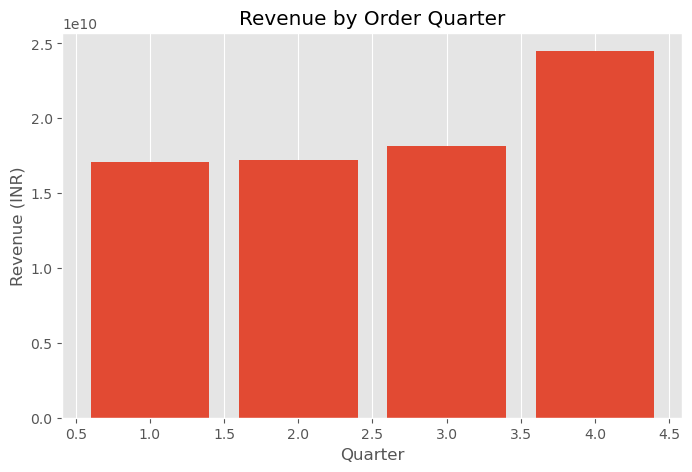

In [40]:
# ==========================================================
# Plot Revenue by Quarter
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    quarter_revenue["order_quarter"],
    quarter_revenue["final_amount_inr"]
)

plt.title("Revenue by Order Quarter")
plt.xlabel("Quarter")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [41]:
# ==========================================================
# Find Highest and Lowest Revenue Quarter
# ==========================================================

highest_quarter = quarter_revenue.iloc[0]
lowest_quarter = quarter_revenue.iloc[-1]

print("Highest Revenue Quarter")
print(highest_quarter)

print()

print("Lowest Revenue Quarter")
print(lowest_quarter)

Highest Revenue Quarter
order_quarter       4.000000e+00
final_amount_inr    2.448965e+10
Name: 3, dtype: float64

Lowest Revenue Quarter
order_quarter       1.000000e+00
final_amount_inr    1.708321e+10
Name: 0, dtype: float64


In [ ]:
# Business Insight

# • Revenue varies across different quarters of the year.

# • The highest revenue-generating quarter represents the strongest sales period.

# • Lower-performing quarters may require seasonal promotions and targeted marketing campaigns.

# • Quarterly revenue analysis helps businesses improve forecasting, inventory planning, and sales strategies.

In [42]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 18
# Revenue by Festival Sale
# ==========================================================

festival_revenue = (
    merged_df
    .groupby("is_festival_sale")["final_amount_inr"]
    .sum()
    .reset_index()
)

festival_revenue

,is_festival_sale,final_amount_inr
0,False,6.027034e+10
1,True,1.661839e+10


In [43]:
# ==========================================================
# Sort Festival Sale Revenue
# ==========================================================

festival_revenue = festival_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

festival_revenue

,is_festival_sale,final_amount_inr
0,False,6.027034e+10
1,True,1.661839e+10


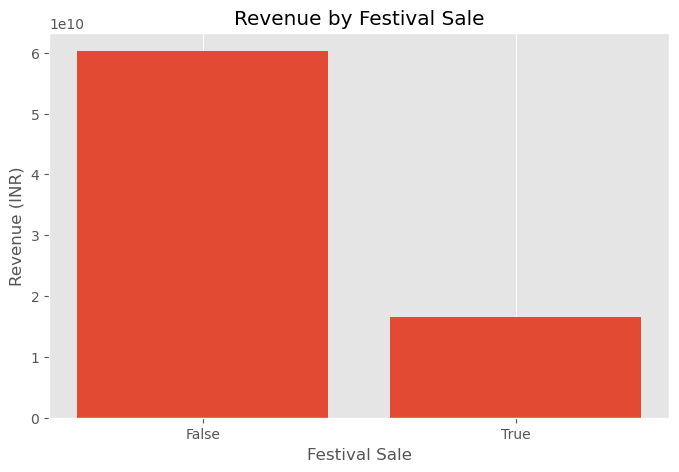

In [44]:
# ==========================================================
# Plot Revenue by Festival Sale
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    festival_revenue["is_festival_sale"].astype(str),
    festival_revenue["final_amount_inr"]
)

plt.title("Revenue by Festival Sale")
plt.xlabel("Festival Sale")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [45]:
# ==========================================================
# Find Highest and Lowest Festival Sale Revenue
# ==========================================================

highest_festival = festival_revenue.iloc[0]
lowest_festival = festival_revenue.iloc[-1]

print("Highest Revenue Group")
print(highest_festival)

print()

print("Lowest Revenue Group")
print(lowest_festival)

Highest Revenue Group
is_festival_sale             False
final_amount_inr    60270337400.25
Name: 0, dtype: object

Lowest Revenue Group
is_festival_sale             True
final_amount_inr    16618392163.0
Name: 1, dtype: object


In [ ]:
# Business Insight

# • Revenue differs between festival sale and non-festival sale orders.

# • The higher revenue group indicates whether festival promotions significantly boost sales.

# • Comparing festival and regular sales helps measure the effectiveness of seasonal campaigns.

# • Festival sale analysis supports better planning for future promotional events and inventory management.

In [46]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 19
# Revenue by Product Weight
# ==========================================================

weight_revenue = (
    merged_df
    .groupby("product_weight_kg")["final_amount_inr"]
    .sum()
    .reset_index()
)

weight_revenue

,product_weight_kg,final_amount_inr
0,0.03,2.908886e+08
1,0.04,6.289903e+08
2,0.05,5.614650e+08
3,0.06,6.042092e+08
4,0.07,7.548986e+08
...,...,...
201,40.26,5.064812e+07
202,41.77,1.932194e+08
203,41.83,3.765574e+07
204,42.38,4.938844e+07


In [47]:
# ==========================================================
# Sort Product Weight by Revenue
# ==========================================================

weight_revenue = weight_revenue.sort_values(
    by="final_amount_inr",
    ascending=False
)

weight_revenue

,product_weight_kg,final_amount_inr
17,0.20,6.731599e+09
18,0.21,6.343063e+09
20,0.23,6.281133e+09
14,0.17,5.524668e+09
19,0.22,5.512432e+09
...,...,...
6,0.09,1.199881e+06
72,0.76,1.165697e+06
130,2.05,1.123488e+06
194,28.90,4.181454e+05


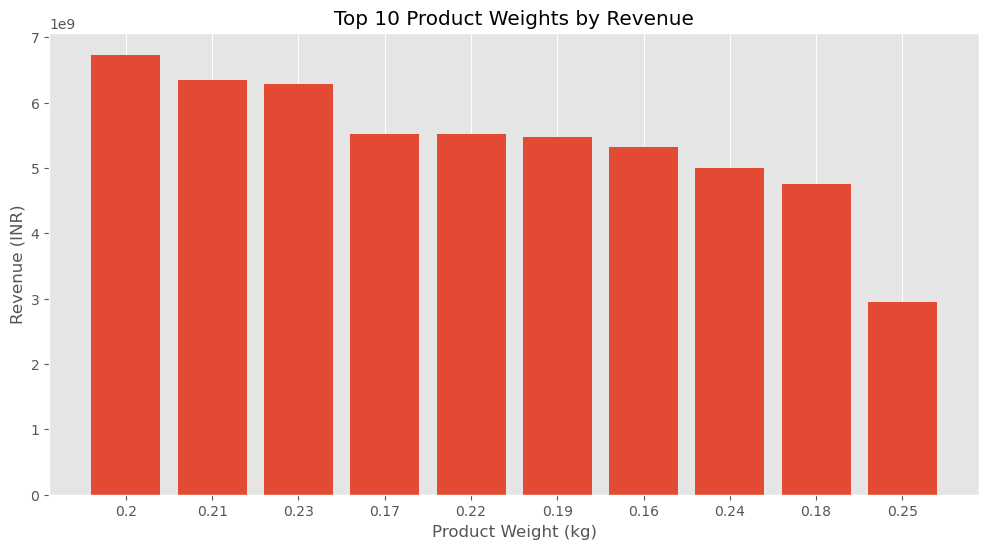

In [48]:
# ==========================================================
# Plot Top 10 Product Weights by Revenue
# ==========================================================

top10_weight = weight_revenue.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10_weight["product_weight_kg"].astype(str),
    top10_weight["final_amount_inr"]
)

plt.title("Top 10 Product Weights by Revenue")
plt.xlabel("Product Weight (kg)")
plt.ylabel("Revenue (INR)")

plt.grid(axis="y")

plt.show()

In [49]:
# ==========================================================
# Find Highest and Lowest Revenue Product Weight
# ==========================================================

highest_weight = weight_revenue.iloc[0]
lowest_weight = weight_revenue.iloc[-1]

print("Highest Revenue Product Weight")
print(highest_weight)

print()

print("Lowest Revenue Product Weight")
print(lowest_weight)

Highest Revenue Product Weight
product_weight_kg    2.000000e-01
final_amount_inr     6.731599e+09
Name: 17, dtype: float64

Lowest Revenue Product Weight
product_weight_kg         0.79
final_amount_inr     184903.89
Name: 75, dtype: float64


In [ ]:
# Business Insight

# • Revenue varies across products with different weights.

# • The highest revenue-generating product weight indicates the most popular product segment.

# • Lower-performing product weights may represent niche or less frequently purchased products.

# • Product weight analysis helps businesses optimize inventory planning, logistics, and shipping costs.

In [50]:
# ==========================================================
# PROJECT PHASE 3 - EXPLORATORY DATA ANALYSIS
# Question 20
# Executive Sales Dashboard Summary
# ==========================================================

print("Total Revenue :", merged_df["final_amount_inr"].sum())
print("Total Orders  :", len(merged_df))
print("Average Order Value :", merged_df["final_amount_inr"].mean())
print("Total Customers :", merged_df["customer_id"].nunique())
print("Total Products :", merged_df["product_id"].nunique())

Total Revenue : 76888729563.25
Total Orders  : 1127609
Average Order Value : 68187.40322509842
Total Customers : 354969
Total Products : 2004


In [51]:
top5_brands = (
    merged_df
    .groupby("brand")["final_amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top5_brands

brand
Samsung    2.062142e+10
Apple      1.632240e+10
OnePlus    1.232417e+10
Xiaomi     5.450159e+09
Realme     3.015664e+09
Name: final_amount_inr, dtype: float64

In [52]:
top5_cities = (
    merged_df
    .groupby("customer_city")["final_amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top5_cities

customer_city
Mumbai       1.065628e+10
Delhi        9.282344e+09
Bangalore    7.680945e+09
Chennai      6.416784e+09
Kolkata      5.053097e+09
Name: final_amount_inr, dtype: float64

In [ ]:
# Executive Summary

# • Revenue showed steady growth over the years before declining in the later period.

# • November recorded the highest monthly revenue.

# • Metro customers contributed the highest revenue.

# • Maharashtra and Mumbai generated the highest regional revenue.

# • Non-Prime customers generated more revenue than Prime customers.

# • Electronics subcategories and leading brands contributed significantly to overall sales.

# • Delivery performance, payment methods, discounts, customer ratings, and festival sales provided valuable insights into customer purchasing behavior.

# • These findings can help improve pricing strategies, inventory planning, marketing campaigns, and business decision-making.

In [7]:
merged_df.dtypes

transaction_id             object
order_date                 object
customer_id                object
product_id                 object
product_name               object
category                   object
subcategory                object
brand                      object
original_price_inr        float64
discount_percent          float64
discounted_price_inr      float64
quantity                    int64
subtotal_inr              float64
delivery_charges          float64
final_amount_inr          float64
customer_city              object
customer_state             object
customer_tier              object
customer_spending_tier     object
customer_age_group         object
payment_method             object
delivery_days               int64
delivery_type              object
is_prime_member              bool
is_festival_sale             bool
festival_name              object
customer_rating           float64
return_status              object
order_month                 int64
order_year    

In [8]:
print(merged_df.dtypes)

transaction_id             object
order_date                 object
customer_id                object
product_id                 object
product_name               object
category                   object
subcategory                object
brand                      object
original_price_inr        float64
discount_percent          float64
discounted_price_inr      float64
quantity                    int64
subtotal_inr              float64
delivery_charges          float64
final_amount_inr          float64
customer_city              object
customer_state             object
customer_tier              object
customer_spending_tier     object
customer_age_group         object
payment_method             object
delivery_days               int64
delivery_type              object
is_prime_member              bool
is_festival_sale             bool
festival_name              object
customer_rating           float64
return_status              object
order_month                 int64
order_year    

In [2]:
df = pd.read_csv("C:\\Users\\CHARU\\OneDrive\\Desktop\\Amazon sales p2\\cleaned_data\\amazon_india_cleaned.csv")

In [4]:
plt.savefig("outputs/rfm_segments.png")

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/rfm_segments.png'

<Figure size 640x480 with 0 Axes>

segment
Potential Loyalists    100853
Loyal Customers         98590
Champions               78344
At Risk                 62179
Lost Customers          15003
Name: count, dtype: int64


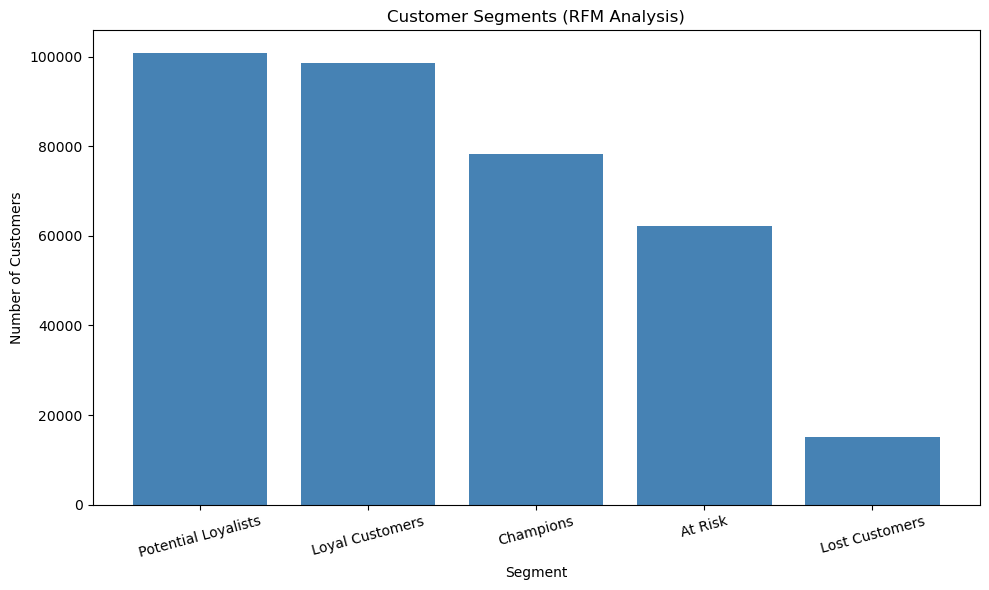

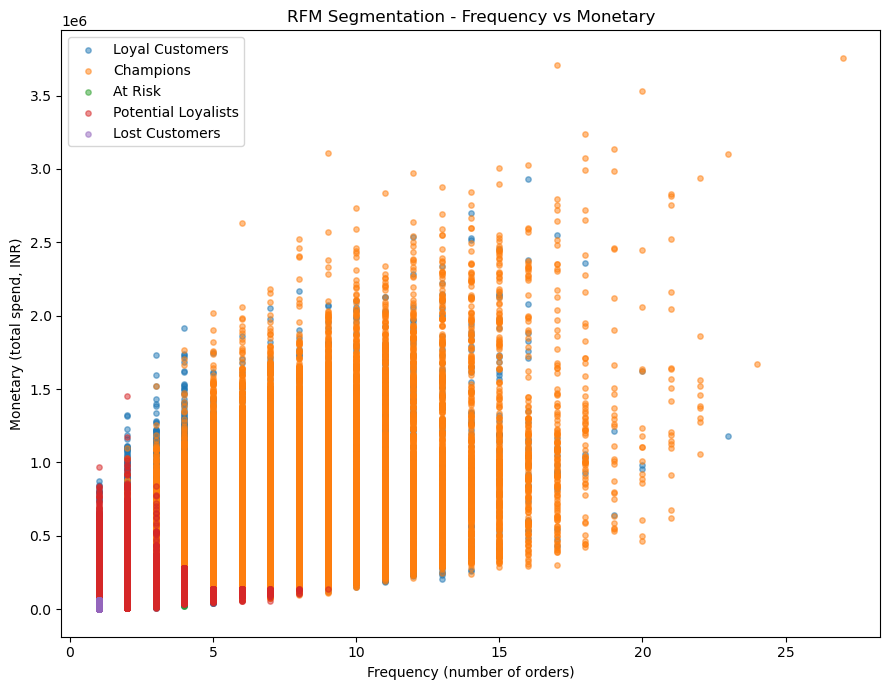

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:\\Users\\CHARU\\OneDrive\\Desktop\\Amazon sales p2\\cleaned_data\\amazon_india_cleaned.csv")
df["order_date"] = pd.to_datetime(df["order_date"])

# Reference date = one day after the last order in the dataset
reference_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_id").agg(
    recency=("order_date", lambda x: (reference_date - x.max()).days),
    frequency=("transaction_id", "count"),
    monetary=("final_amount_inr", "sum")
).reset_index()

# Score each metric into quartiles (4 = best, 1 = worst)
rfm["R_score"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)

rfm["RFM_total"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def segment_customer(score):
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal Customers"
    elif score >= 6:
        return "Potential Loyalists"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost Customers"

rfm["segment"] = rfm["RFM_total"].apply(segment_customer)

print(rfm["segment"].value_counts())

# Visualization
plt.figure(figsize=(10, 6))
segment_counts = rfm["segment"].value_counts()
plt.bar(segment_counts.index, segment_counts.values, color="steelblue")
plt.title("Customer Segments (RFM Analysis)")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/rfm_segments.png")
plt.show()

# Scatter: Frequency vs Monetary, colored by segment
plt.figure(figsize=(9, 7))
for seg in rfm["segment"].unique():
    subset = rfm[rfm["segment"] == seg]
    plt.scatter(subset["frequency"], subset["monetary"], label=seg, alpha=0.5, s=15)
plt.xlabel("Frequency (number of orders)")
plt.ylabel("Monetary (total spend, INR)")
plt.title("RFM Segmentation - Frequency vs Monetary")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/rfm_scatter.png") 
rfm.to_csv("../outputs/rfm_segments.csv", index=False)
plt.show()



In [11]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="amazon_sales_db",
    user="postgres",
    password="naiim@2482",
    port="5432"
)
cur = conn.cursor()

cur.execute("""
CREATE TABLE IF NOT EXISTS customers AS
SELECT DISTINCT customer_id, customer_city, customer_state, customer_tier,
       customer_spending_tier, customer_age_group, is_prime_member
FROM amazon_sales;
""")

cur.execute("""
CREATE TABLE IF NOT EXISTS products AS
SELECT DISTINCT product_id, product_name, category, subcategory, brand
FROM amazon_sales;
""")

cur.execute("CREATE INDEX IF NOT EXISTS idx_customer_id ON amazon_sales(customer_id);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_order_date ON amazon_sales(order_date);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_customer_state ON amazon_sales(customer_state);")

conn.commit()
cur.close()
conn.close()
print("customers and products tables created, indexes added")

customers and products tables created, indexes added


In [12]:
import psycopg2
import pandas as pd

conn = psycopg2.connect(host="localhost", database="amazon_sales_db", user="postgres", password="naiim@2482", port="5432")
print("Customers:", pd.read_sql_query("SELECT COUNT(*) FROM customers;", conn))
print("Products:", pd.read_sql_query("SELECT COUNT(*) FROM products;", conn))
conn.close()

Customers:     count
0  454541
Products:    count
0   2004


C:\Users\CHARU\AppData\Local\Temp\ipykernel_3520\1242172565.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print("Customers:", pd.read_sql_query("SELECT COUNT(*) FROM customers;", conn))
C:\Users\CHARU\AppData\Local\Temp\ipykernel_3520\1242172565.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print("Products:", pd.read_sql_query("SELECT COUNT(*) FROM products;", conn))


InterfaceError: cursor already closed